Dean Hickman

CS 251: Data Analysis and Visualization

# Lab 3b | Polynomial Regression

In [1]:
import os
import random
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from data import Data

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 15})
plt.rcParams.update({'figure.figsize': (10,6)})

np.set_printoptions(suppress=True, precision=5)

## Task 1: Import  datasets

1. Import fit (`'data/lab3b-400-fit.csv'`) and validation ('data/lab3b-100-val.csv') datasets into separate ndarrays using [genfromtxt](https://docs.scipy.org/doc/numpy/reference/generated/numpy.genfromtxt.html) or your `Data` class.
2. The column 'x' is the independent variable.  Columns 'y1', 'y2', and 'y3' are dependent variables.  We will only be using y1.
3. Print the first 5 rows of each dataset.
4. Plot your dataset, column 'x' and 'y1', with a title and axis labeled. 

Dataset [Af] first 5 rows:
 [[ 0.86084 -0.62216  3.93574 11.60028]
 [-0.30754  0.00447  4.675    8.86444]
 [ 0.77201 -0.79127  3.94762 10.83111]
 [-0.71808 -0.75327 11.83894  5.23568]
 [-0.28735  0.01856  8.7937   8.49431]]
Dataset [Av] first 5 rows:
 [[-0.91878 -0.9357  22.11518  4.98345]
 [-0.92811 -1.16687 18.58222  3.34313]
 [-0.96837 -1.36751 13.3575   3.65102]
 [-0.96436 -1.62782 13.88831  4.08888]
 [-0.97014 -1.2789  24.96344  3.74772]]

--------------------------------------
Your results should look like
--------------------------------------
Fit dataset [Af] first 5 rows:
[[ 0.86084 -0.62216  3.93574 11.60028]
 [-0.30754  0.00447  4.675    8.86444]
 [ 0.77201 -0.79127  3.94762 10.83111]
 [-0.71808 -0.75327 11.83894  5.23568]
 [-0.28735  0.01856  8.7937   8.49431]]
Validation dataset [Av] first 5 rows:
[[-0.91878 -0.9357  22.11518  4.98345]
 [-0.92811 -1.16687 18.58222  3.34313]
 [-0.96837 -1.36751 13.3575   3.65102]
 [-0.96436 -1.62782 13.88831  4.08888]
 [-0.97014 -1.2789  24

Text(0.5, 0, 'X')

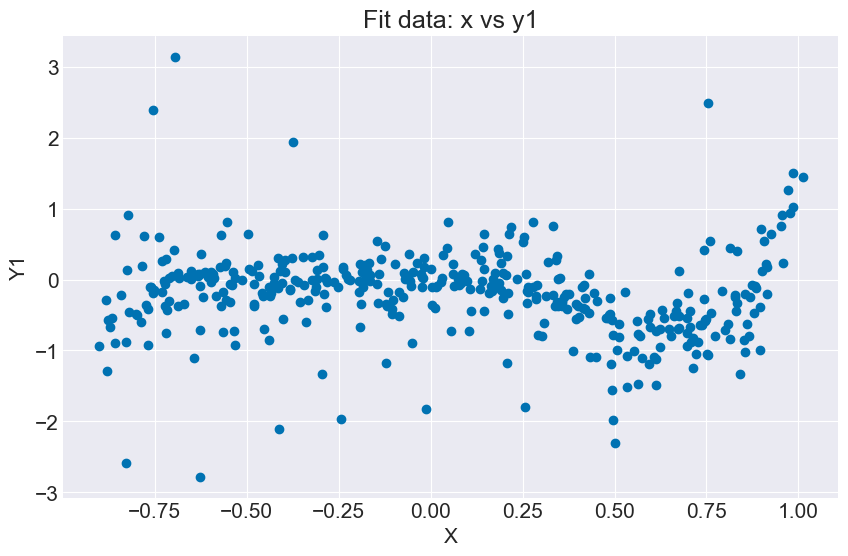

In [2]:
Af= np.genfromtxt('data/lab3b-400-fit.csv', delimiter= ",", dtype= float, skip_header= 2)
Av= np.genfromtxt('data/lab3b-100-val.csv', delimiter= ",", dtype= float, skip_header= 2)

print("Dataset [Af] first 5 rows:\n" , Af[:5])
print("Dataset [Av] first 5 rows:\n" , Av[:5])

print('''
--------------------------------------
Your results should look like
--------------------------------------
Fit dataset [Af] first 5 rows:
[[ 0.86084 -0.62216  3.93574 11.60028]
 [-0.30754  0.00447  4.675    8.86444]
 [ 0.77201 -0.79127  3.94762 10.83111]
 [-0.71808 -0.75327 11.83894  5.23568]
 [-0.28735  0.01856  8.7937   8.49431]]
Validation dataset [Av] first 5 rows:
[[-0.91878 -0.9357  22.11518  4.98345]
 [-0.92811 -1.16687 18.58222  3.34313]
 [-0.96837 -1.36751 13.3575   3.65102]
 [-0.96436 -1.62782 13.88831  4.08888]
 [-0.97014 -1.2789  24.96344  3.74772]]
''')

Af=Data('data/lab3b-400-fit.csv')
Av = Data('data/lab3b-100-val.csv')
plt.scatter(Af.select_data(['x']), Af.select_data(['y1']))
plt.title("Fit data: x vs y1")
plt.ylabel("Y1")
plt.xlabel("X")


## Task 2: Degree 3 Polynomial Regression

### 2a. Make 3 ndarrays

$$
\left(\begin{array}{cccc} 
1 & x_0^1 & x_0^2 & x_0^3\\
1 & x_1^1 & x_1^2 & x_1^3\\
1 & x_2^1 & x_2^2 & x_2^3\\
1 & x_3^1 & x_3^2 & x_3^3\\
1 & x_4^1 & x_4^2 & x_4^3\\
... & ... & ... & ...\\
1 & x_{N-1}^1 & x_{N-1}^2 & x_{N-1}^3\\
\end{array}\right)
$$ 

1. Make a 2D polynomial ndarray for the fit dataset using the independent variable
    2. Create a matrix of [ones](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html), `A1f`, with the same number of rows as the fit dataset and 4 columns.
    5. Update the second column to be the respective x column, the third column to be the respective x column squared, and the fourth column to be the respective x column cubed.
    1. Print the first 5 rows of the matrix
2. Make a 2D polynomial ndarray for the validation dataset
    3. Create a matrix of [ones](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html), `A1v`, with the same number of rows as the validation dataset and 4 columns
    5. Like in the step above, update the second column to be the respective x column, the third column to be the respective x column squared, and the fourth column to be the respective x column cubed.
    1. Print the first 5 rows of the matrix
3. Make a 2D polynomial ndarray to graph the values on the regression curve.
    1. Create a 1D ndarray via [linspace](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linspace.html), `line_x`, spanning the range (i.e. min/max) of the validation dataset's x column values with 100 steps.
    2. Create a matrix of [ones](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html), `x_p`, with the same number of rows as the length of `line_x` and 4 columns
    3. Update the second column to be `line_x`, the third column to be `line_x` squared, and the fourth column to be `line_x` cubed.
    4. Print the first 5 rows of the matrix


In [3]:
Af=Data('data/lab3b-400-fit.csv')
Av = Data('data/lab3b-100-val.csv')

A1f = np.hstack((np.ones((Af.get_num_samples(), 1)), Af.select_data(['x']), Af.select_data(['x'])**2, Af.select_data(['x'])**3))
A1v = np.hstack((np.ones((Av.get_num_samples(), 1)), Av.select_data(['x']), Av.select_data(['x'])**2, Av.select_data(['x'])**3))
line_x = np.linspace(np.min(Av.select_data(['x'])), np.max(Av.select_data(['x'])), 100).reshape(100,1)
x_p = np.hstack((np.ones((line_x.shape[0], 1)), line_x, line_x**2, line_x**3))

print("A1f first 5 rows:\n" , A1f[:5])
print("A1v first 5 rows:\n" , A1v[:5])
print("x_p first 5 rows:\n" , x_p[:5])

print('''
--------------------------------------
Your results should look like
--------------------------------------
A1f first 5 rows
[[ 1.       0.86084  0.74104  0.63792]
 [ 1.      -0.30754  0.09458 -0.02909]
 [ 1.       0.77201  0.596    0.46012]
 [ 1.      -0.71808  0.51564 -0.37027]
 [ 1.      -0.28735  0.08257 -0.02373]]
A1v first 5 rows
[[ 1.      -0.91878  0.84417 -0.77561]
 [ 1.      -0.92811  0.86139 -0.79946]
 [ 1.      -0.96837  0.93773 -0.90807]
 [ 1.      -0.96436  0.92999 -0.89685]
 [ 1.      -0.97014  0.94118 -0.91308]]
x_p first 5 rows
[[ 1.      -0.97014  0.94118 -0.91308]
 [ 1.      -0.94925  0.90107 -0.85534]
 [ 1.      -0.92835  0.86183 -0.80008]
 [ 1.      -0.90745  0.82347 -0.74726]
 [ 1.      -0.88656  0.78598 -0.69682]]
''')

A1f first 5 rows:
 [[ 1.       0.86084  0.74104  0.63792]
 [ 1.      -0.30754  0.09458 -0.02909]
 [ 1.       0.77201  0.596    0.46012]
 [ 1.      -0.71808  0.51564 -0.37027]
 [ 1.      -0.28735  0.08257 -0.02373]]
A1v first 5 rows:
 [[ 1.      -0.91878  0.84417 -0.77561]
 [ 1.      -0.92811  0.86139 -0.79946]
 [ 1.      -0.96837  0.93773 -0.90807]
 [ 1.      -0.96436  0.92999 -0.89685]
 [ 1.      -0.97014  0.94118 -0.91308]]
x_p first 5 rows:
 [[ 1.      -0.97014  0.94118 -0.91308]
 [ 1.      -0.94925  0.90107 -0.85534]
 [ 1.      -0.92835  0.86183 -0.80008]
 [ 1.      -0.90745  0.82347 -0.74726]
 [ 1.      -0.88656  0.78598 -0.69682]]

--------------------------------------
Your results should look like
--------------------------------------
A1f first 5 rows
[[ 1.       0.86084  0.74104  0.63792]
 [ 1.      -0.30754  0.09458 -0.02909]
 [ 1.       0.77201  0.596    0.46012]
 [ 1.      -0.71808  0.51564 -0.37027]
 [ 1.      -0.28735  0.08257 -0.02373]]
A1v first 5 rows
[[ 1.      -0.91

### 2b. Calculate Degree 3 Polynomial Regression
1.  Use [scipy.linalg.lstsq]() to calculate and print the fitted coefficients and MSE for the dependent variable `yf`. 
2.  Print the $R^2$ value computed on the fit set.
    

In [4]:
y1f = Af.select_data(['y1'])
c, _, _, _ = scipy.linalg.lstsq(A1f, y1f)

print(f"c: {c.flatten()}")
y1fPred = A1f @ c
resid = y1f - y1fPred

mse = np.sum(resid**2)/y1f.shape[0]
print(f"MSE: {mse}")
r2f = 1 - np.sum(resid**2) / np.sum((y1f - np.mean(y1f))**2)
print(f"r-squared: {r2f}")

print('''
--------------------------------------
Your results should look like
--------------------------------------
c: [-0.15511 -0.96979 -0.24675  1.61541]
MSE: 0.3431335215559479
r-squared: 0.11595609001119211
''')

c: [-0.15511 -0.96979 -0.24675  1.61541]
MSE: 0.3431335215559478
r-squared: 0.11595609001119211

--------------------------------------
Your results should look like
--------------------------------------
c: [-0.15511 -0.96979 -0.24675  1.61541]
MSE: 0.3431335215559479
r-squared: 0.11595609001119211



### 2c. Testing and prediction

1. Calculate the $R^2$ for the linear regressions ability predict the test dataset
    1.  Multiply `A1v` (*validation set*) with the fitted coefficients to get the predicted values
    2.  Calculate the $R^2$ value and print it computed with the *validation set* the dependent variable values `yv`.
    > $R^2 = 1 - \frac{\sum_i \left (y_i - \hat{y}_i \right )^2}{\sum_i \left (y_i - \bar{y} \right )^2}$ <br> <br> $y_i$ are the dependent variable values from the validation dataset <br> $\bar{y}$ is the mean of the dependent variable values from the validation dataset <br> $\hat{y}_i$ is the y values *predicted* by the regression

2. Print the $R^2$ for the test dataset

In [7]:
#A1v = Data('data/lab3b-100-val.csv')
#A1v = np.hstack((np.ones((Av.get_num_samples(), 1)), Av.select_data(['x']), Av.select_data(['x'])**2, Av.select_data(['x'])**3))

y1vPred= A1v @ c
y1v = Av.select_data(['y1'])
residv= y1v - y1vPred
r2v= 1- np.sum(residv**2)/ np.sum((y1v-np.mean(y1v))**2)

print(f"r2 validation: {r2v}")
print('''
--------------------------------------
Your results should look like
--------------------------------------
r2 validation: 0.4431027176546438
''')

r2 validation: 0.4431027176546438

--------------------------------------
Your results should look like
--------------------------------------
r2 validation: 0.4431027176546438



## Task 3: Visualize the Results
In one plot:
1. Graph the fit set data as a scatter plot.
1. Graph the validation set data as a scatter plot (different color markers).
1. Graph the prediction regression curve
    1. the independent variable is `line_x`
    2. the dependent variable is `x_p` multiplied with the fitted coefficients.
2. Include a title (with the two $R^2$ values), axis labels, and a legend

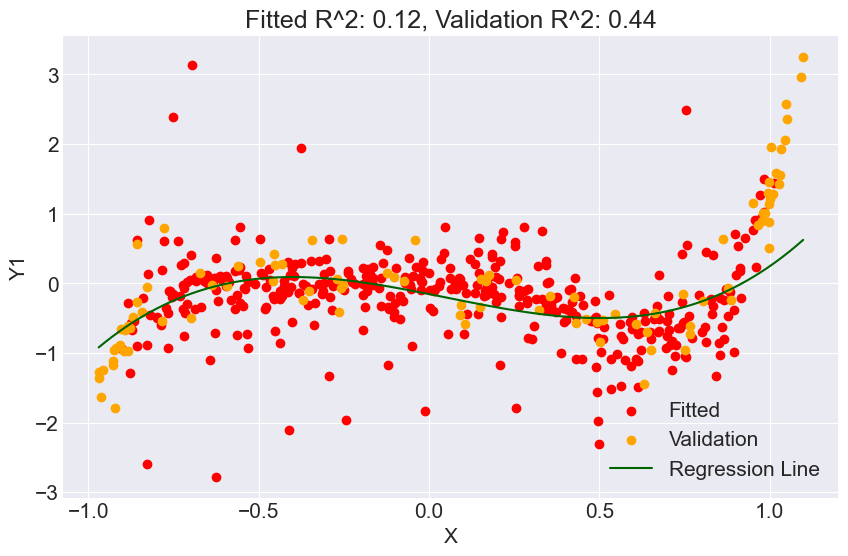

In [13]:
xf = Af.select_data(['x'])
xv = Av.select_data(['x'])

plt.scatter(xf, y1f, color = 'red', label = 'Fitted')
plt.scatter(xv, y1v, color = 'orange', label = 'Validation')
plt.plot(line_x, x_p@c, color = 'darkgreen', label = 'Regression Line')
plt.xlabel('X')
plt.ylabel('Y1')
plt.title("Fitted R^2: {:.2f}, Validation R^2: {:.2f}".format(r2f, r2v))
plt.legend(loc="best")
plt.show()

## Turn in your lab

Follow the usual submission format and submit your lab on Google Classroom.